In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sp
import matplotlib.pyplot as plt

In [103]:
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [101]:
data = pd.read_csv('/kaggle/input/competitions/playground-series-s5e11/train.csv')

In [102]:
data

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [118]:
data = data.drop_duplicates()
data.isna().sum()

id                        0
annual_income             0
debt_to_income_ratio      0
credit_score              0
loan_amount               0
interest_rate             0
education_level           0
employment_status         0
grade_subgrade            0
loan_paid_back            0
loan_purpose_Business     0
loan_purpose_Education    0
loan_purpose_Home         0
loan_purpose_Medical      0
loan_purpose_Vacation     0
dtype: int64

Data doesn't have any missed values

### **EDA**

In [107]:
cat_col = ['gender', 
           'marital_status', 'education_level', 'employment_status',
           'loan_purpose', 	'grade_subgrade']
cont_col = ['annual_income', 'debt_to_income_ratio', 
            'credit_score', 	'loan_amount', 	'interest_rate']
target = 'loan_paid_back'


<Axes: xlabel='loan_paid_back', ylabel='count'>

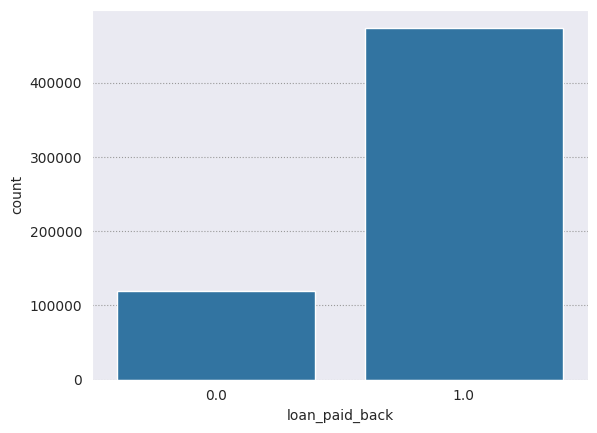

In [105]:
sns.countplot(data = data, x = target)

As you can see, data has an imbalanced target distribution

annual_income -- 0.006325654110711386
debt_to_income_ratio -- -0.3356799274592322
credit_score -- 0.2345598060773147
loan_amount -- -0.003762185458822347
interest_rate -- -0.13118406693159013


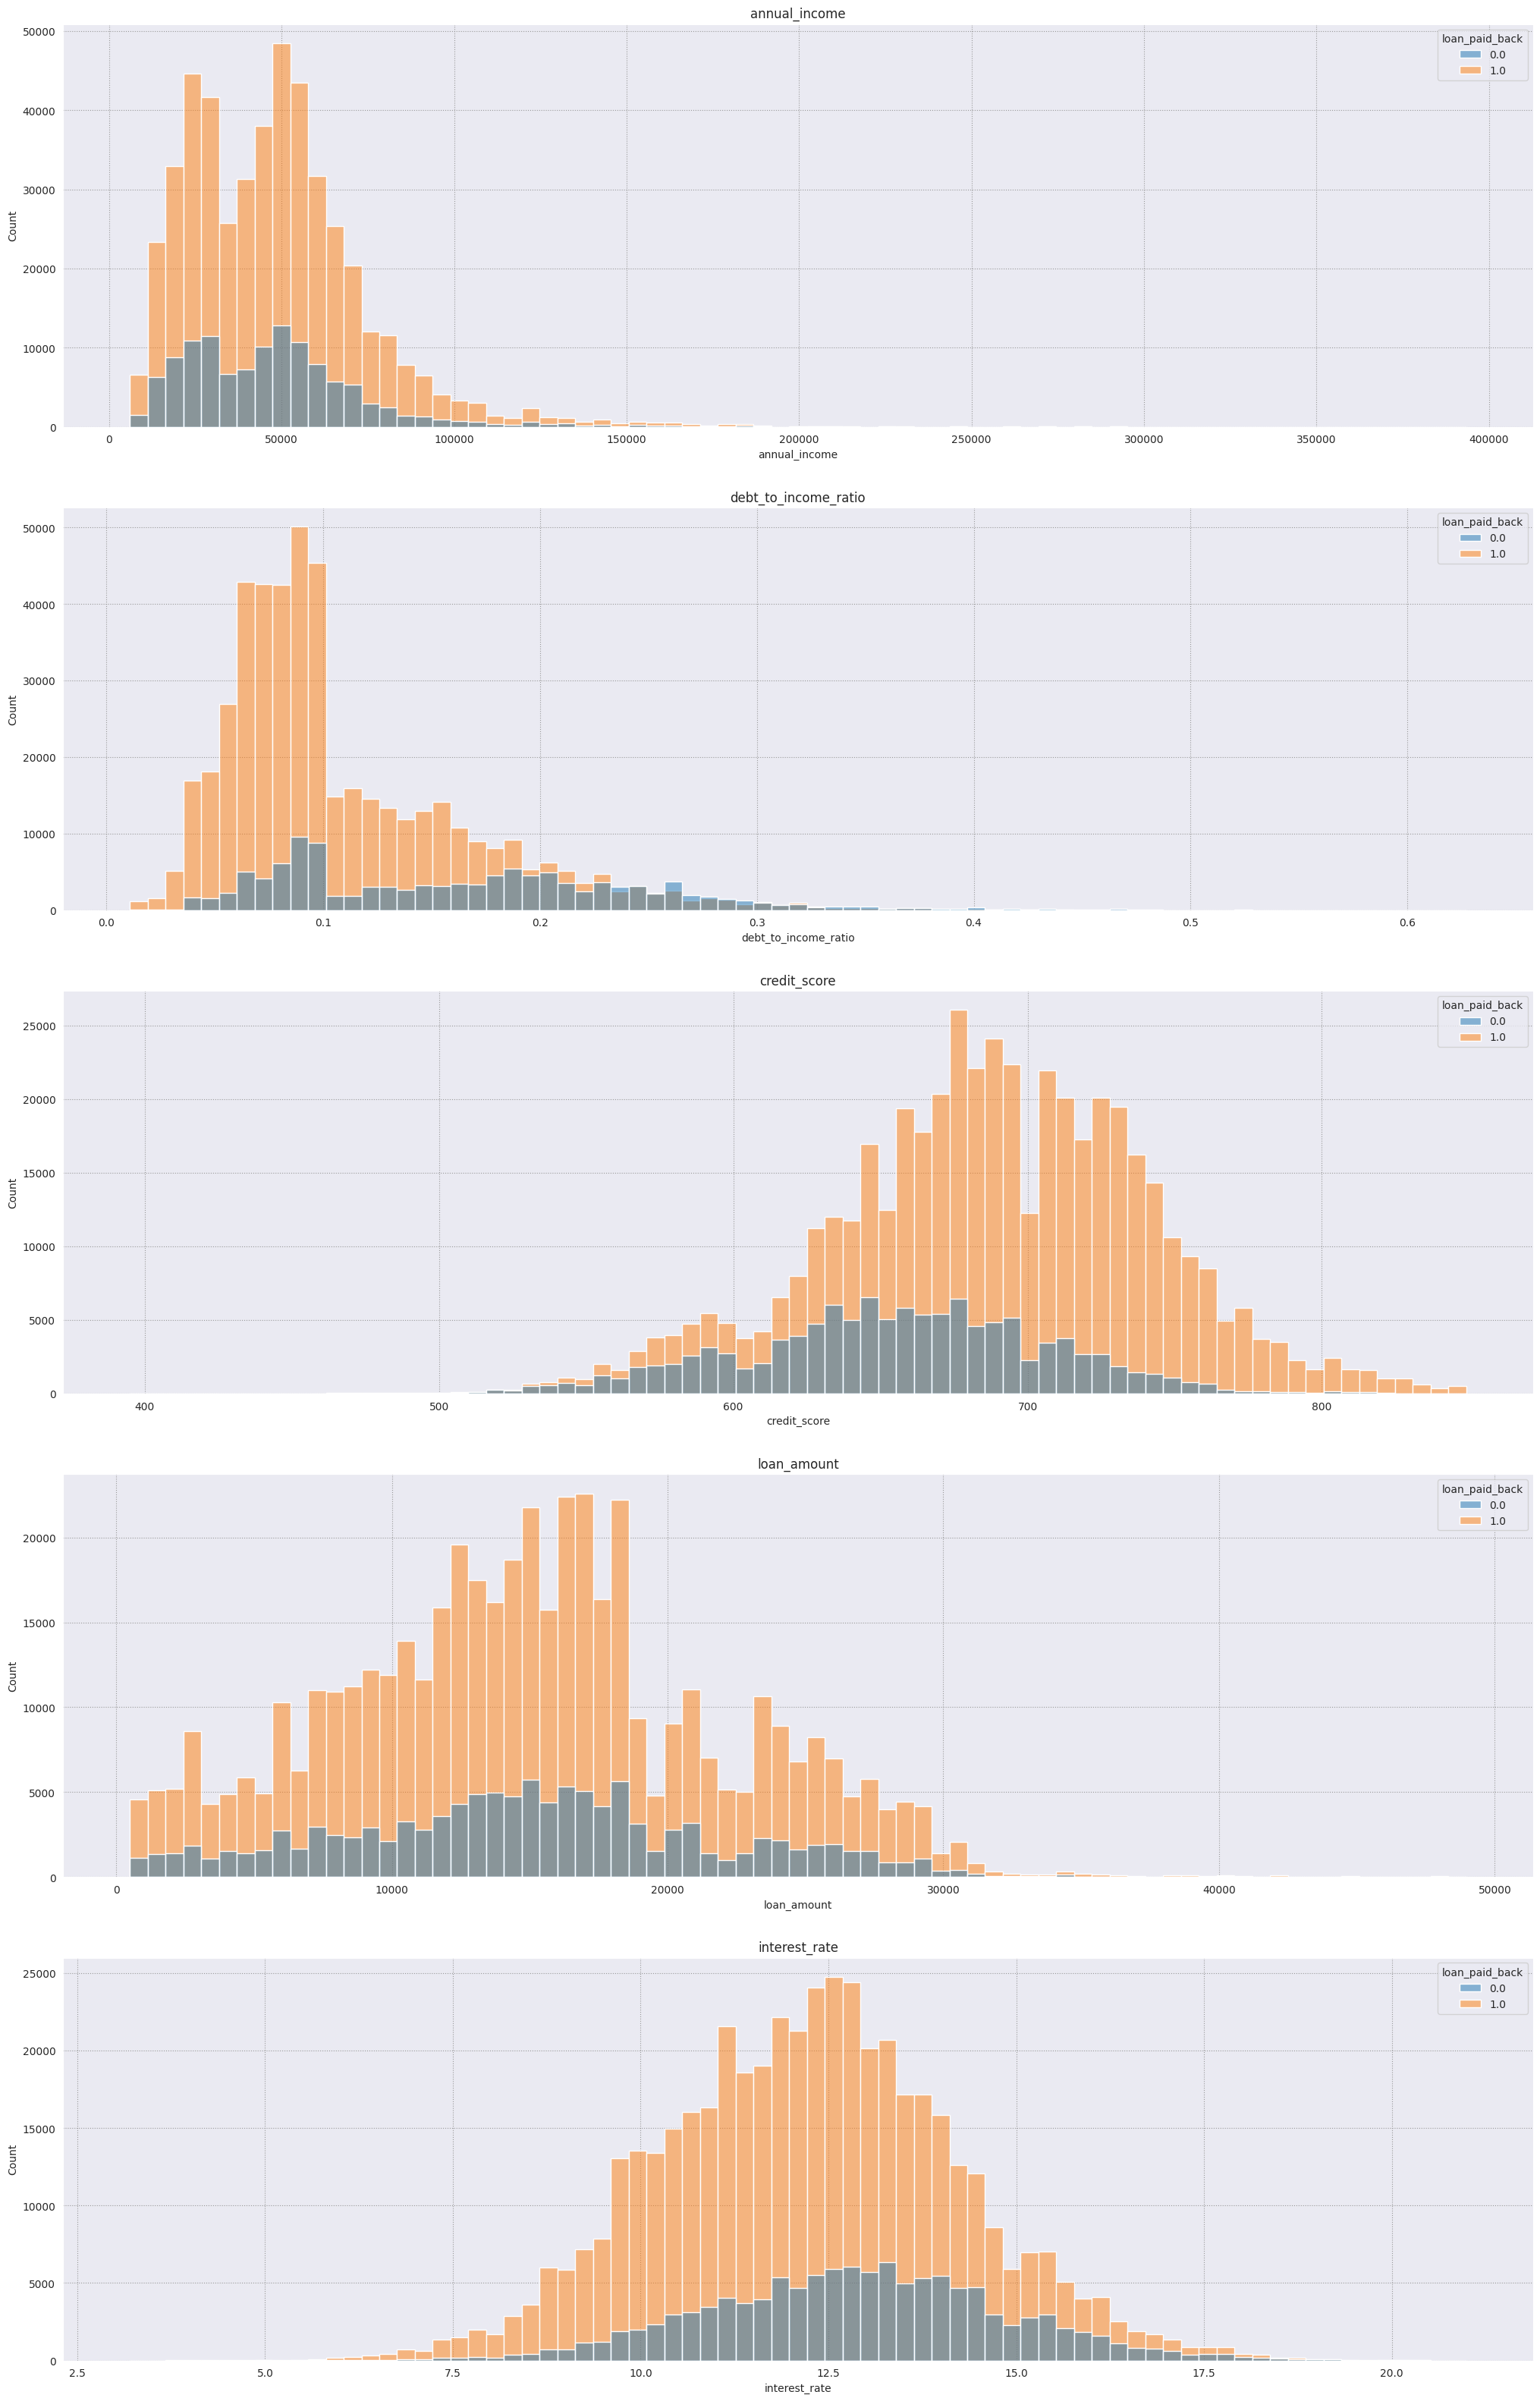

In [108]:
fig, axes = plt.subplots(len(cont_col), figsize = (25, 40))
i = 0
for col in cont_col:
    statistic = sp.stats.pointbiserialr(data[col], data[target]).statistic
    print(f"{col} -- {statistic}")
    sns.histplot(data = data, x = col, hue = target,
                 ax = axes[i], bins = 75).set_title(col)
    i += 1
    '''
    if statistic >= 0.85:
        data.drop(columns = col, inplace = True)
    '''


In [109]:


def plot(data, x, target):
    df1 = data.groupby(x)[target].value_counts(normalize=True)
    df1 = df1.mul(100)
    df1 = df1.rename('percent').reset_index()
    
    g = sns.catplot(x=x,y='percent',hue=target,kind='bar',data=df1, height = 7, aspect = 3)
    g.ax.set_ylim(0,100)
        
    for p in g.ax.patches:
        txt = str(round(p.get_height(), 2)) + '%'
        txt_x = p.get_x() 
        txt_y = p.get_height()
        g.ax.text(txt_x,txt_y,txt)

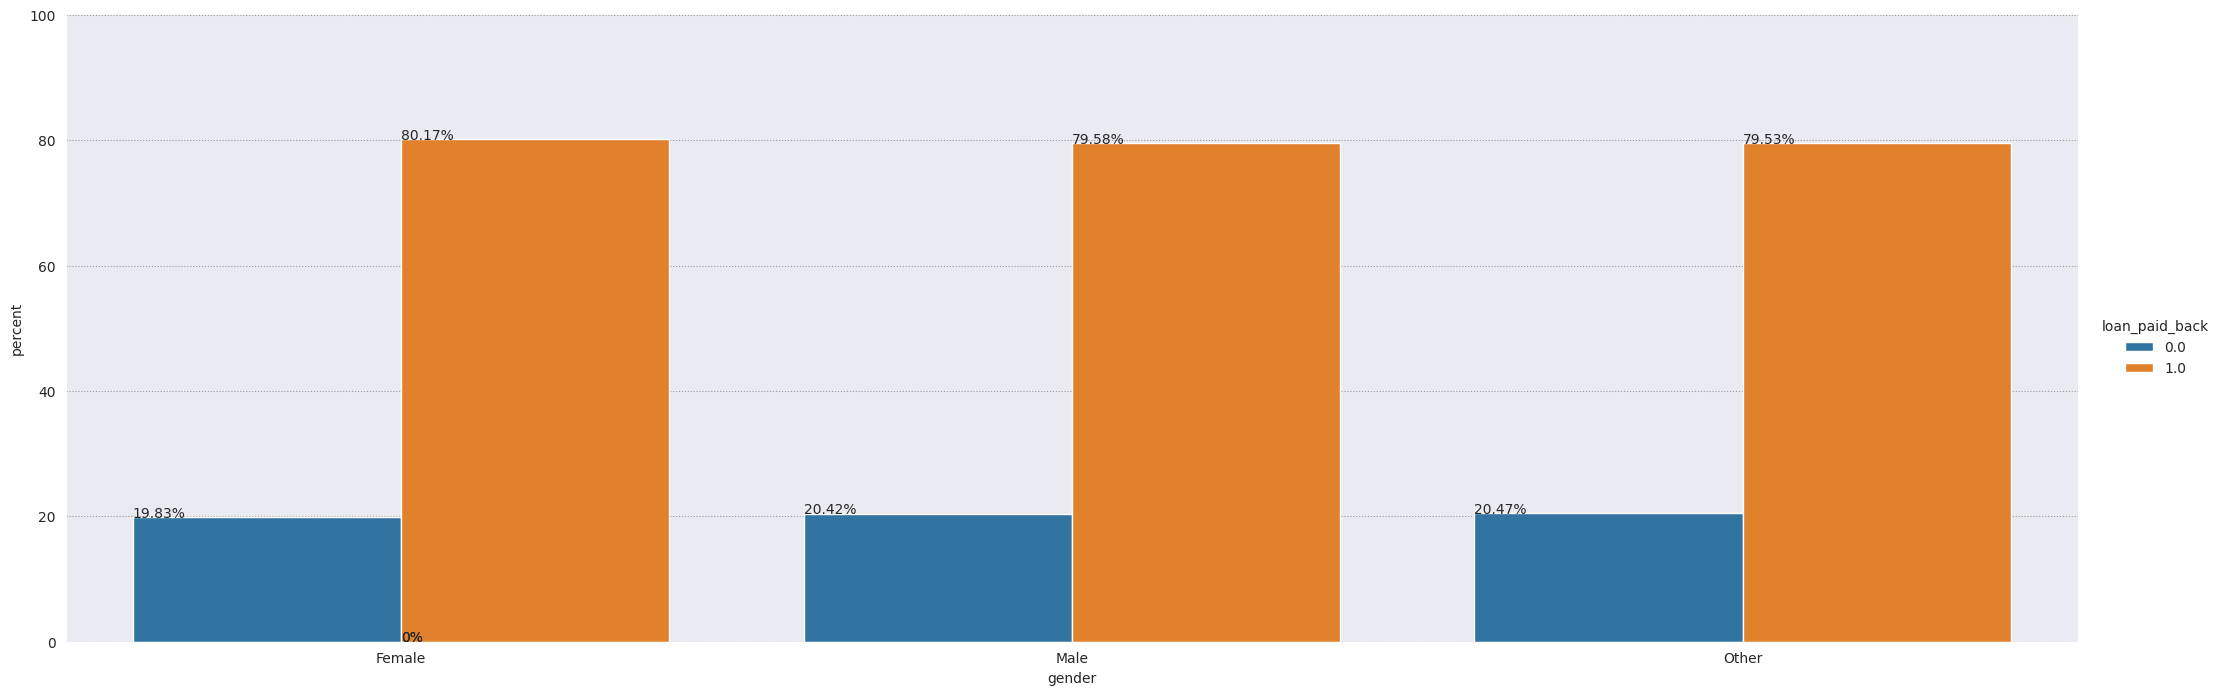

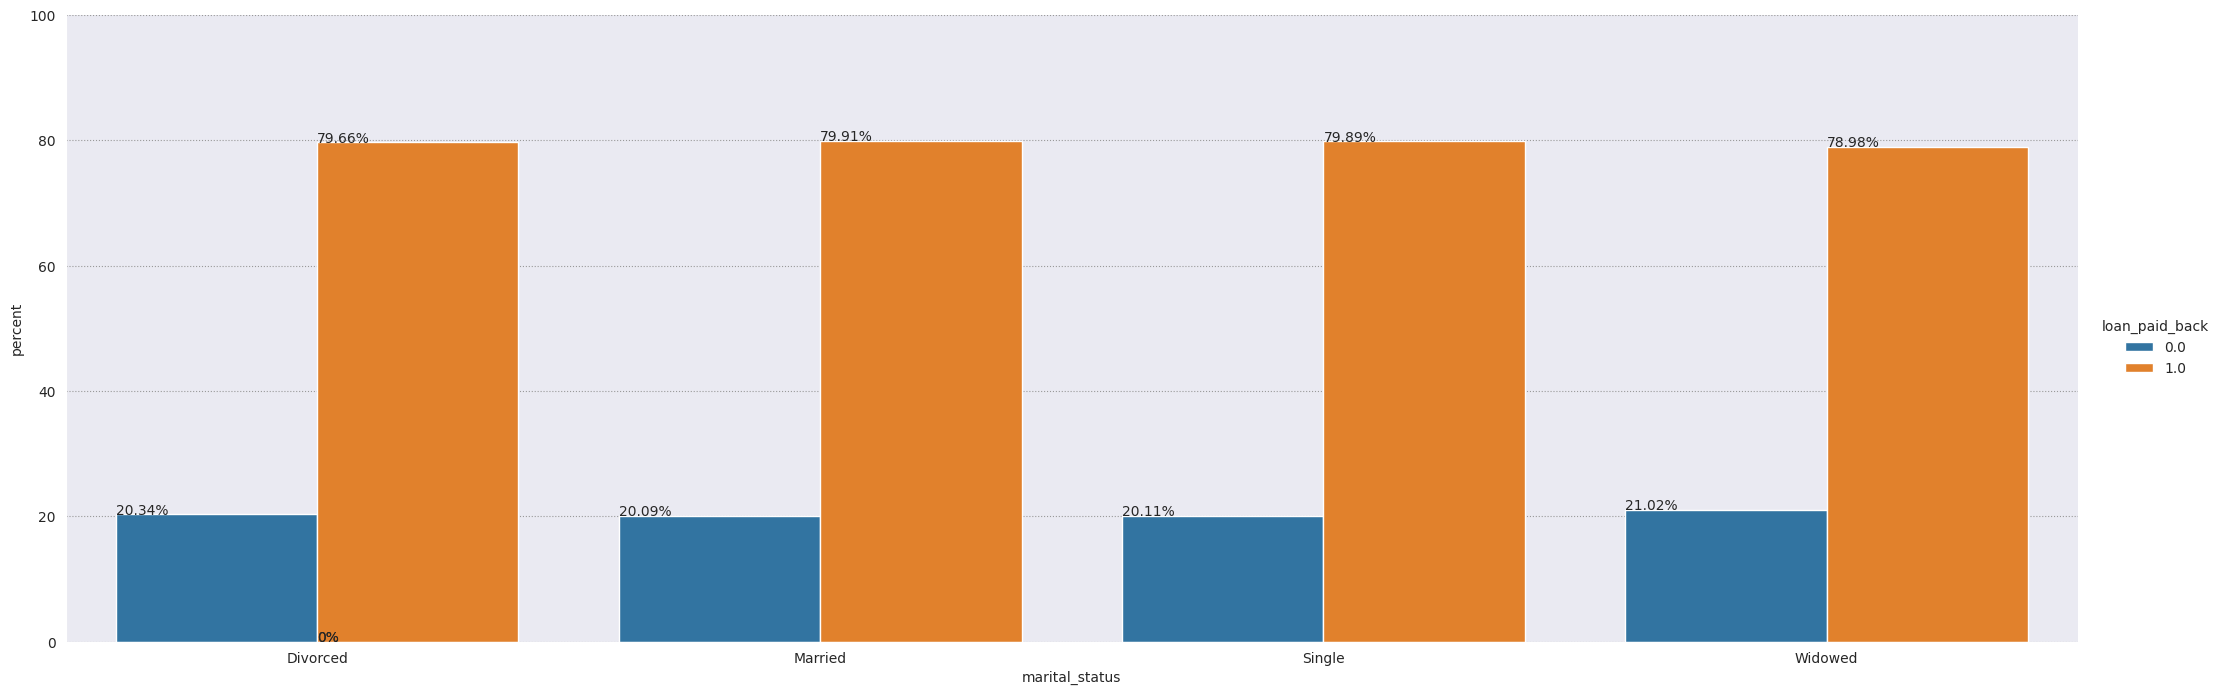

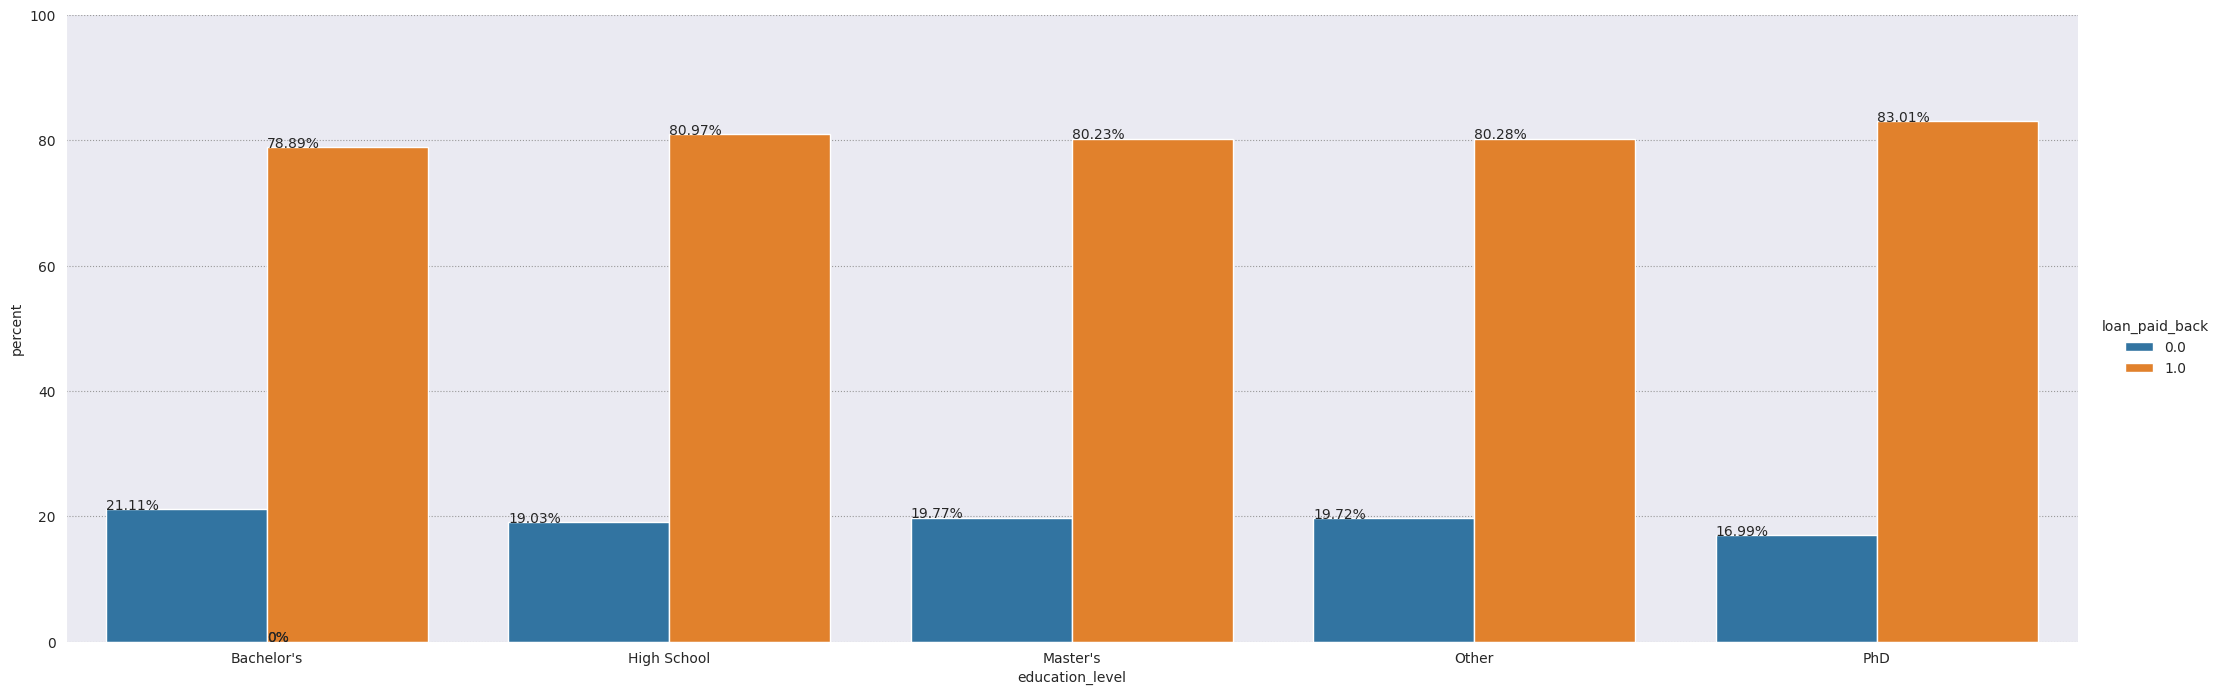

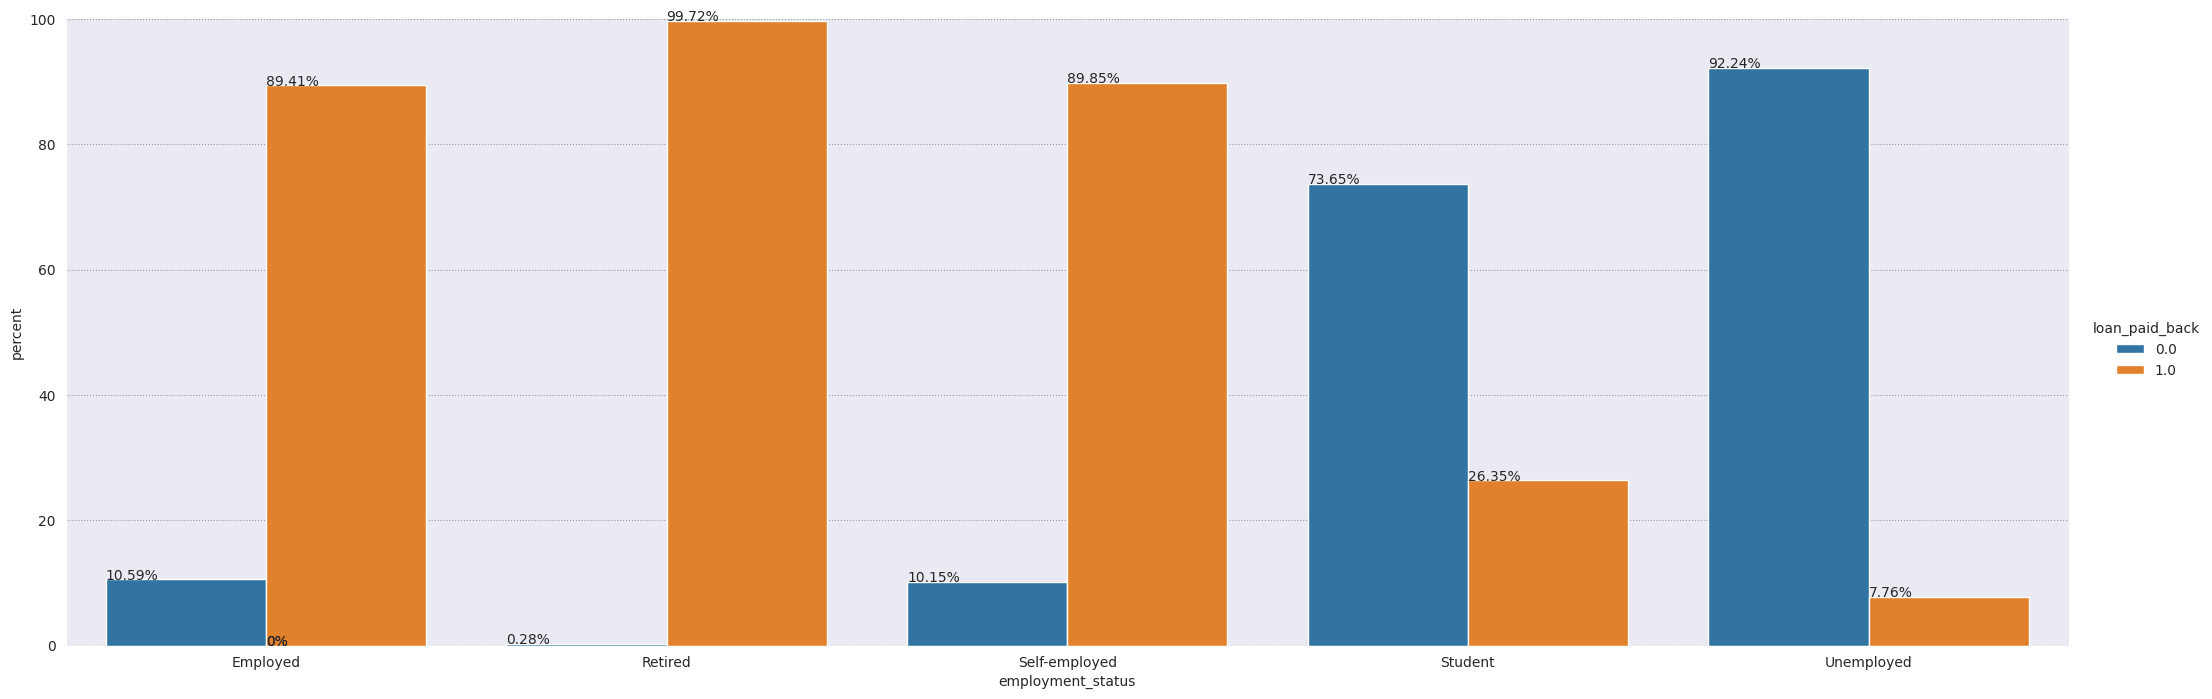

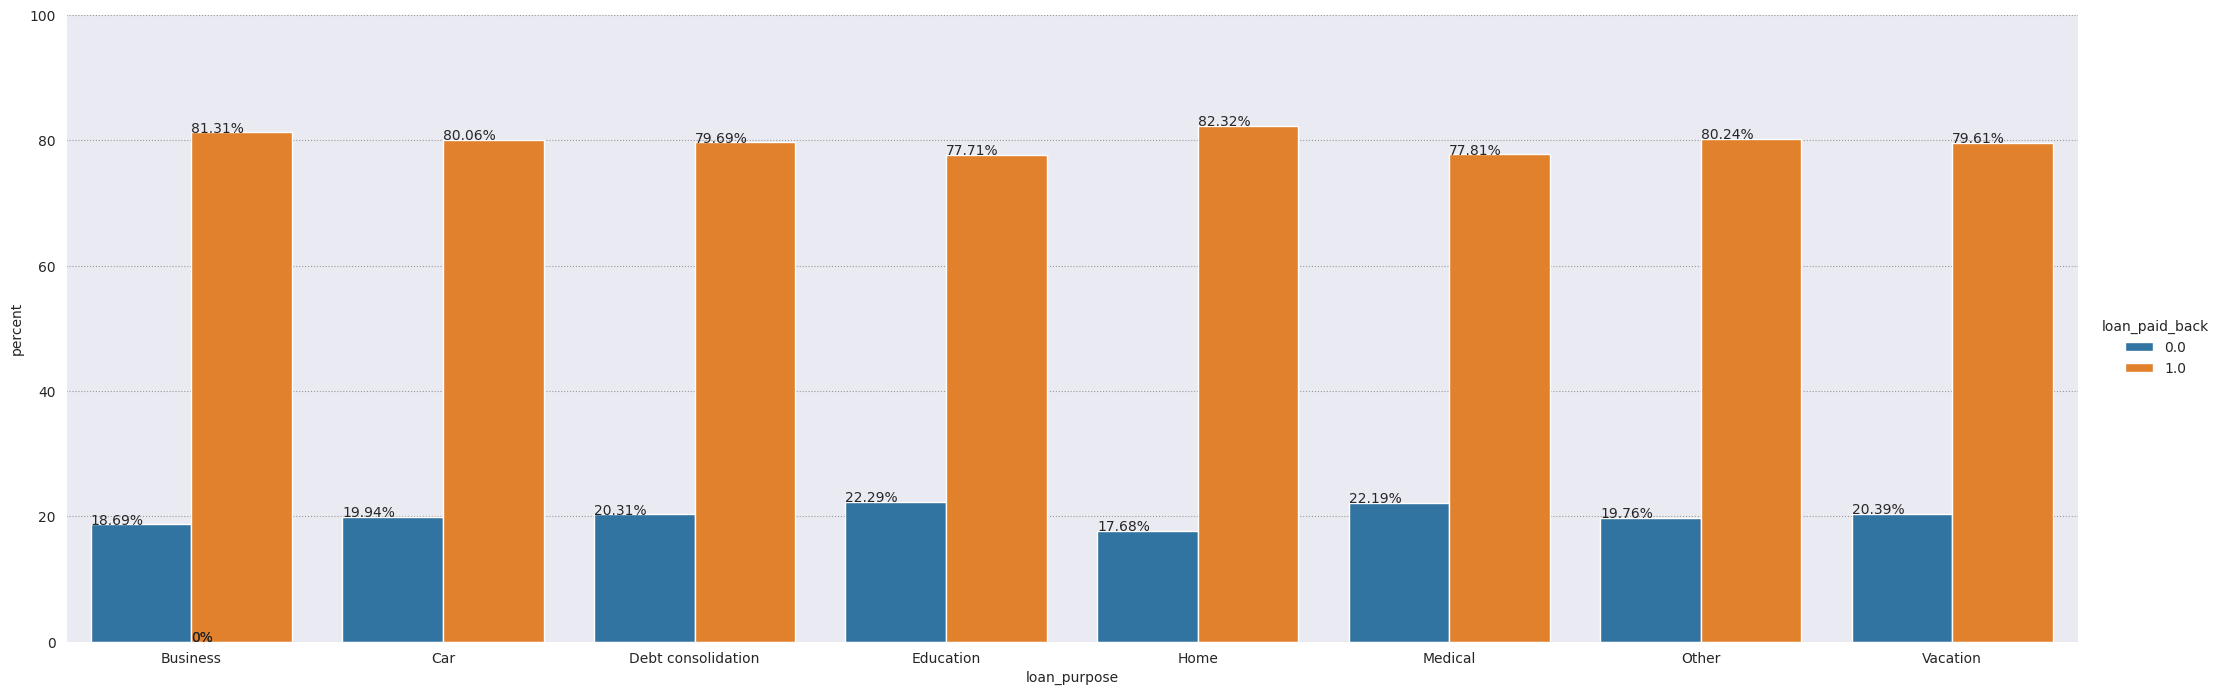

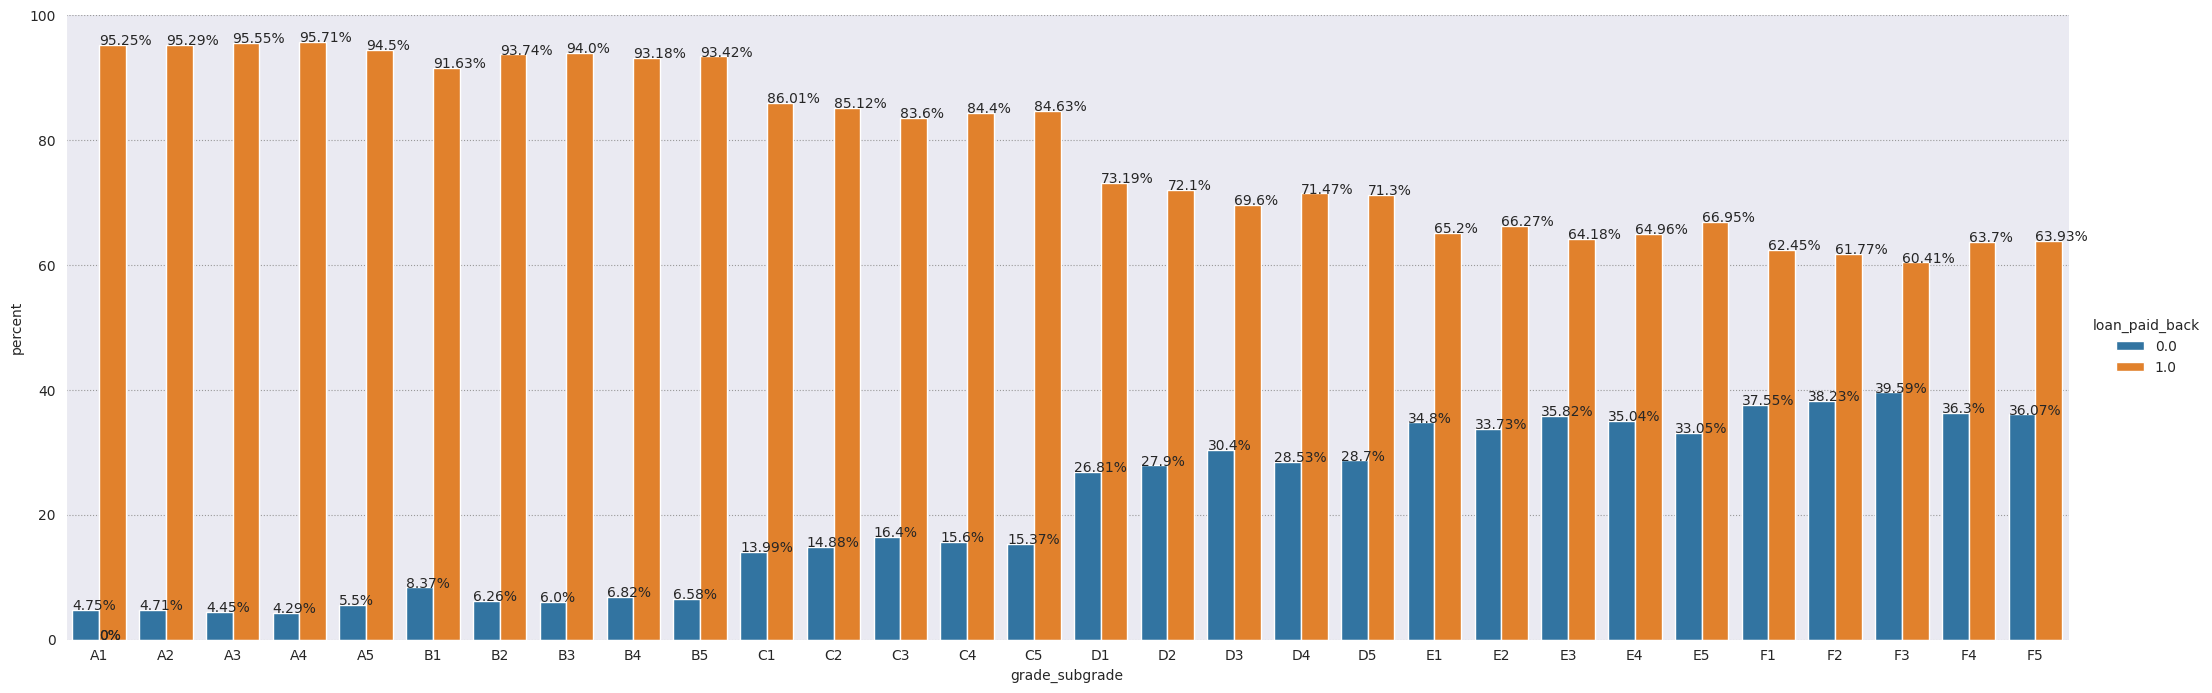

In [110]:
for i in range(len(cat_col)):
    plot(data, cat_col[i], target)

We observe neither marital status nor gender have a significant impact on predicting a loan paid back. But employment status and with grade_subgrade with some arrangment of the last have it 

Let's explore what's the differences between employment_status and specific loan purposes

In [20]:
all_purposes = data.groupby('employment_status')[target].value_counts(normalize=True).reset_index().sort_values(by=["employment_status", "loan_paid_back"])
all_purposes

,employment_status,loan_paid_back,proportion
1,Employed,0.0,0.105855
0,Employed,1.0,0.894145
3,Retired,0.0,0.002796
2,Retired,1.0,0.997204
5,Self-employed,0.0,0.101543
4,Self-employed,1.0,0.898457
6,Student,0.0,0.736485
7,Student,1.0,0.263515
8,Unemployed,0.0,0.922381
9,Unemployed,1.0,0.077619


In [48]:
unique_purposes = data['loan_purpose'].unique()
all_purposes = data.groupby('employment_status')[target].value_counts(normalize=True).reset_index().sort_values(by=["employment_status", "loan_paid_back"])
for purpose in unique_purposes:
    subdata = data[data['loan_purpose'] == purpose]
    df1 = subdata.groupby('employment_status')[target].value_counts(normalize=True).reset_index().sort_values(by=["employment_status", "loan_paid_back"])
    df1 = pd.merge(df1, all_purposes, how = 'right', on = ['employment_status', 'loan_paid_back'])
    df1.fillna(0, inplace = True)
    
    df1['difference'] = abs(df1['proportion_x'] - df1['proportion_y'])
    print(f"{purpose} -- \n mean: {round(df1['difference'].mean(), 4)}  max -- {round(df1['difference'].max(), 4)}",
            f"min -- {round(df1['difference'].min(), 4)}"
                    )
    

Other -- 
 mean: 0.0045  max -- 0.0091 min -- 0.0028
Debt consolidation -- 
 mean: 0.0013  max -- 0.0038 min -- 0.0001
Home -- 
 mean: 0.0192  max -- 0.0617 min -- 0.0017
Education -- 
 mean: 0.014  max -- 0.0334 min -- 0.0008
Vacation -- 
 mean: 0.0071  max -- 0.0135 min -- 0.0024
Car -- 
 mean: 0.0036  max -- 0.0075 min -- 0.0008
Medical -- 
 mean: 0.0133  max -- 0.0387 min -- 0.0012
Business -- 
 mean: 0.0079  max -- 0.0238 min -- 0.0019


As you can see, loan_paid back for loan purpose for Debt consolidation, Car or for Other purposes isn't siginifact different compared to a grouped together employment_status. So we drop them with marital_status and gender as insignificant variables 

In [111]:
data = pd.get_dummies(data, columns=['loan_purpose'])
data.drop(columns = ['loan_purpose_Other', 'loan_purpose_Debt consolidation',
                      'loan_purpose_Car'], inplace = True)

In [112]:
data.drop(columns = ['gender', 'marital_status'], inplace = True)

<Axes: xlabel='employment_status', ylabel='loan_amount'>

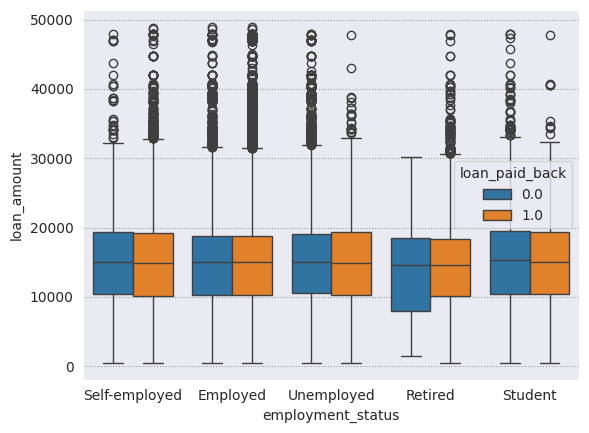

In [113]:
sns.boxplot(data = data, x = 'employment_status', y = 'loan_amount', hue = target)

<Axes: xlabel='employment_status', ylabel='interest_rate'>

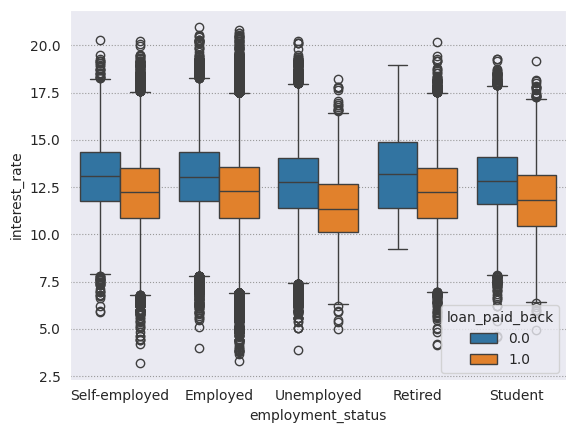

In [114]:
sns.boxplot(data = data, x = 'employment_status', y = 'interest_rate', hue = target)

<Axes: xlabel='employment_status', ylabel='debt_to_income_ratio'>

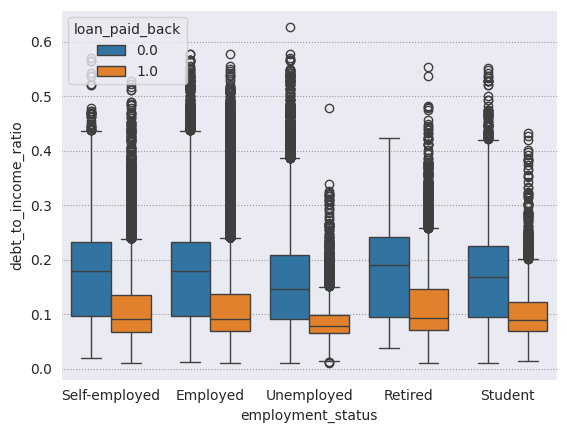

In [115]:
sns.boxplot(data = data, x = 'employment_status', y = 'debt_to_income_ratio', hue = target)

<Axes: xlabel='employment_status', ylabel='credit_score'>

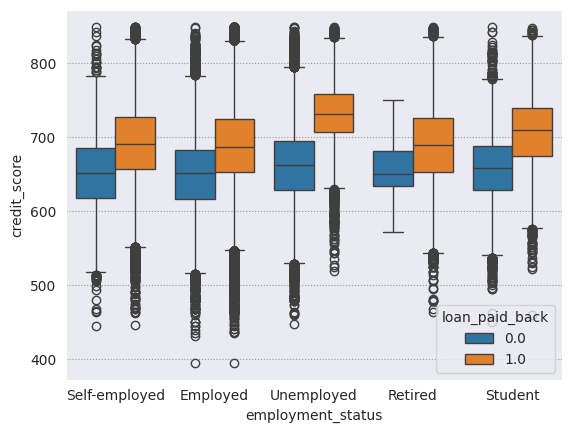

In [116]:
sns.boxplot(data = data, x = 'employment_status', y = 'credit_score', hue = target)

Because we already have debt_to_income_proportion, what can explain more about a paying back capability, we can drop annual_income and loan_amount

In [119]:

data.drop(columns = ['annual_income', 'loan_amount', 'id'], inplace = True)
data['grade'] = data['grade_subgrade'].apply(lambda x: x[0])


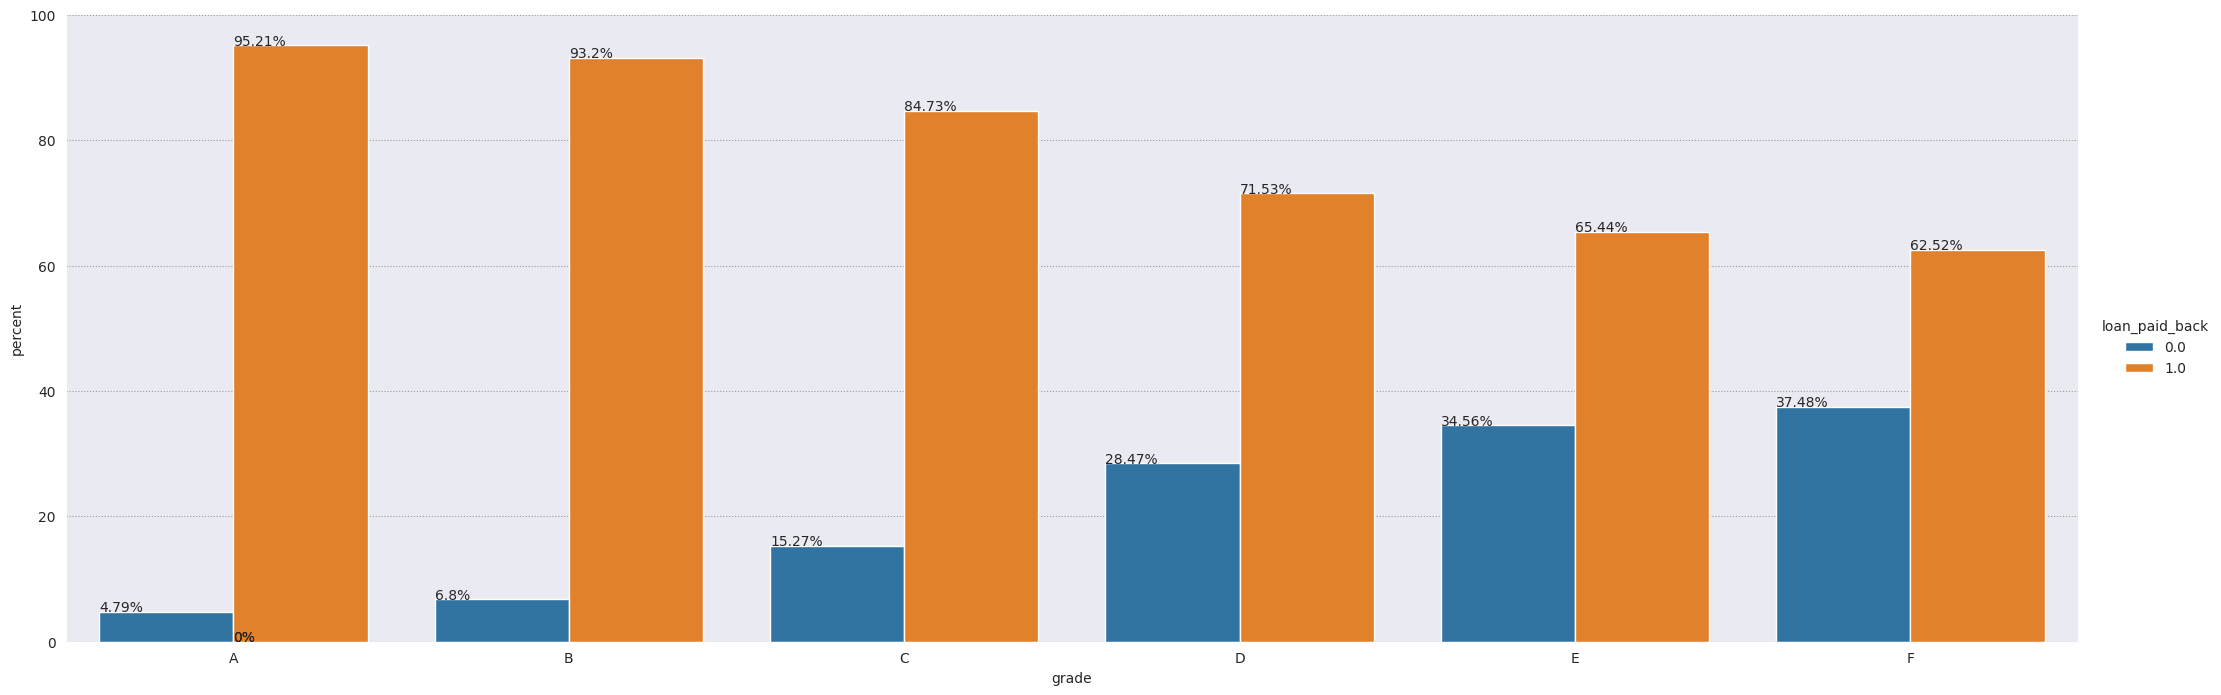

In [120]:
plot(data, 'grade', target)

We can see a significant increasing a statistical correlation between grade and loan_paid_back

In [121]:
data.drop(columns = ['grade_subgrade'], inplace = True)

In [122]:
data

,debt_to_income_ratio,credit_score,interest_rate,education_level,employment_status,loan_paid_back,loan_purpose_Business,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Vacation,grade
0,0.084,736,13.67,High School,Self-employed,1.0,False,False,False,False,False,C
1,0.166,636,12.92,Master's,Employed,0.0,False,False,False,False,False,D
2,0.097,694,9.76,High School,Employed,1.0,False,False,False,False,False,C
3,0.065,533,16.10,High School,Employed,1.0,False,False,False,False,False,F
4,0.053,665,10.21,High School,Employed,1.0,False,False,False,False,False,D
...,...,...,...,...,...,...,...,...,...,...,...,...
593989,0.152,703,10.92,High School,Employed,1.0,True,False,False,False,False,C
593990,0.105,559,14.62,Bachelor's,Employed,1.0,False,False,False,False,False,F
593991,0.072,675,14.13,Bachelor's,Employed,1.0,False,False,False,False,False,C
593992,0.067,740,9.87,Bachelor's,Employed,1.0,False,False,False,False,False,B


### **Training XGBClassifier and Predicting**


In [123]:
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
rb = RobustScaler()

X = data.drop(columns = target)
y = data[target]

cat_col = ['education_level', 	'employment_status', 'grade']
cont_col = ['debt_to_income_ratio', 'credit_score', 'interest_rate']

X = pd.get_dummies(X, columns=cat_col)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

#X_train[cont_col] = rb.fit_transform(X_train[cont_col])
#X_test[cont_col] = rb.transform(X_test[cont_col])
# create model instance


In [124]:
bst = XGBClassifier(n_estimators=100, 
                    max_depth=5, learning_rate=0.01, subsample = 0.85, min_child_weight = 3, device = 'cuda',
                    objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)

In [125]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, preds)
classification_rep = classification_report(y_test, preds)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.90

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.52      0.68     23897
         1.0       0.89      0.99      0.94     94902

    accuracy                           0.90    118799
   macro avg       0.92      0.76      0.81    118799
weighted avg       0.90      0.90      0.89    118799



In [126]:
bst = XGBClassifier(n_estimators=1000, 
                    max_depth=15, learning_rate=0.01, subsample = 0.85, min_child_weight = 3, device = 'cuda',
                    objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)

In [128]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, preds)
classification_rep = classification_report(y_test, preds, digits=4)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.9030

Classification Report:
               precision    recall  f1-score   support

         0.0     0.8726    0.6064    0.7155     23897
         1.0     0.9079    0.9777    0.9415     94902

    accuracy                         0.9030    118799
   macro avg     0.8903    0.7920    0.8285    118799
weighted avg     0.9008    0.9030    0.8961    118799



In the second version of model, recall score for negative class and f1-score increased. For loaning it's better to not loss money, so we can trade off precision to improve recall. 

### **Submitting results**

In [136]:
test = pd.read_csv('/kaggle/input/competitions/playground-series-s5e11/test.csv')
test

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1
...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2


In [137]:
test['grade'] = test['grade_subgrade'].apply(lambda x: x[0])
test = pd.get_dummies(test, columns=['loan_purpose'])
test.drop(columns = ['loan_purpose_Other', 'loan_purpose_Debt consolidation',
                      'loan_purpose_Car'], inplace = True)
_id = test.id
test.drop(columns = ['id', 'annual_income', 'loan_amount',
                     'gender', 'marital_status',
                     'grade_subgrade'], inplace = True)


In [138]:
to_predict = pd.get_dummies(test, columns=cat_col)
preds = bst.predict(to_predict)

In [139]:
submission = pd.DataFrame({'id': _id, target: preds})
filename = f'submission.csv'
submission.to_csv(filename, index=False)


###  **Possible impovements**

We could observe outlies on the boxplots. So it better to analyze the best method to deal with them.

Also it's better to add correlation heatmap between variables and, probably, Variable Inflation Factor


And for model it's better to check its perfomance on Cross-Validation